# Chapter 2 (cont.) — Binomial, Chi-Square, and Poisson Distributions

Covers the back half of Ch 2 of *Practical Statistics for Data Scientists*: Binomial Distribution → Chi-Square Distribution → Poisson Distribution, applied to the Ames Housing dataset.

**Chi-Square gets a short scaffolded lead-in below** — the book introduces it thinly here as a "reference distribution" and only pays it off later (Ch 3's chi-square test), so there's less to anchor to. Ask for a hint if you get stuck; per the repo's review protocol, the first couple of asks per question get a nudge, not the answer.

Primary tools: pandas / numpy for data wrangling, scipy.stats for the distributions themselves.

In [142]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime

# scrollable df
pd.set_option("display.max_columns", None)

# load df
ames = pd.read_csv('../data/ames_housing.csv')
ames.shape

(2930, 81)

## 1. Binomial Distribution

Pick a binary condition in Ames — e.g. `Central_Air == 'Y'`, or `Fireplaces > 0`, or `Overall_Qual >= 7` — and treat its dataset-wide proportion as the true success probability `p`.

1. If you drew a random sample of `n = 25` houses (independent draws, i.e. with replacement), what does the *binomial* distribution say about how many of them would meet your condition? Compute the full PMF, then report `P(X = k)` for the actual count you'd expect (`k = round(n*p)`), and `P(X >= k)` for some higher threshold you pick.
2. Cross-check: draw an actual random sample of `n` houses from the dataframe and see where its count falls in that distribution.
3. For a condition with `p` far from 0.5 (like the ~95% `Central_Air == 'Y')` versus one close to 0.5 (like `Fireplaces > 0`), compare the shape of the binomial PMF. The book notes the normal distribution approximates the binomial when `n*p` and `n*(1-p)` are both reasonably large — for which of your two conditions does that approximation look better at `n=25`, and why?

In [143]:
# establish binary condition (fairly new construction <= 10 years)
ames["is_new"] = ames["Year_Built"] >= 2000
ames["is_new"] = ames["is_new"].astype(int)
success_p = ames["is_new"].sum()/ames["is_new"].count()
print(f"Success probability of fairly new construction: {success_p} or {round(success_p * 100,2)}%")

Success probability of fairly new construction: 0.2672354948805461 or 26.72%


In [144]:
# get k 
n = 25
k = round(n * success_p)
print(f"Expected number of success: {k}") 

Expected number of success: 7


* This represents the expected value/count of houses that would meet our condition. 
* This is also known as the mean of the binomial distribution
* used as a value of PMF (probability mass function)

In [145]:
# compute the pmf
scipy.stats.binom.pmf(k,n,success_p)

np.float64(0.17357722762389485)

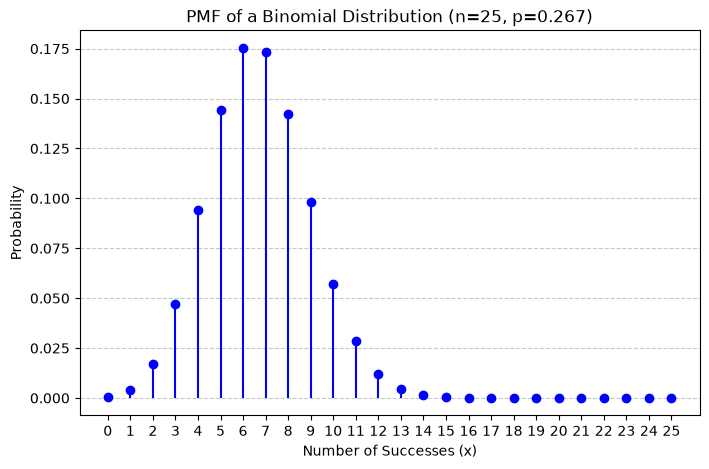

In [146]:
x = np.arange(0, n + 1)
pmf_values = scipy.stats.binom.pmf(x,n,success_p)

# Create the stem plot
plt.figure(figsize=(8, 5))
plt.stem(x, pmf_values, basefmt=" ", linefmt="b-", markerfmt="bo")

# Format the plot
plt.title("PMF of a Binomial Distribution (n=25, p=0.267)")
plt.xlabel("Number of Successes (x)")
plt.ylabel("Probability")
plt.xticks(x)  # Force integer ticks on x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

* This is the result of the probability mass function PMF.
* It represents P(X = k). What this means is that it represents the probability that your sameple lands on exactly 7 "fairly new" houses.
* In plain english it means theres a 17.4% chance a random batch of 25 hourses gives you exactly 7 fairly-new ones.

In [147]:
# tail analysis: probability of 10 or more of my houses drawn are considered fairly new
tail_p = scipy.stats.binom.cdf(9, n, success_p)
print(f"Probabaility of getting 10 successes or more in the sample drawn: {1- tail_p}")

# sf() gets you the same thing
print(scipy.stats.binom.sf(9, n, success_p))

Probabaility of getting 10 successes or more in the sample drawn: 0.10411018501217217
0.10411018501217217


* cdf: gives you the probability of achieving X number of successes or less.
* sf: gives you the probability of achieving X + 1 number of success or more.
* In our case, the probability of getting 10 houses that are considered fairly new in our 25-house sample is 10.4%


In [148]:
# draw an actual sample and compare to PMF results
sample = ames.sample(25, replace= True, random_state=42)
num_sucesses = sample["is_new"].sum()
# how many new houses
print(f"# of fairly new houses: {num_sucesses}")
# how typical was your draw
print(f"probability of {num_sucesses} fairly new houses: {(scipy.stats.binom.pmf(num_sucesses,n,success_p)) * 100}%")

# of fairly new houses: 9
probability of 9 fairly new houses: 9.811628879011213%


True Central AC Probability: 93.31058020477816%
Expected value: 23.32764505119454
Probability of getting 23.0 houses with central AC in your sample 27.31%


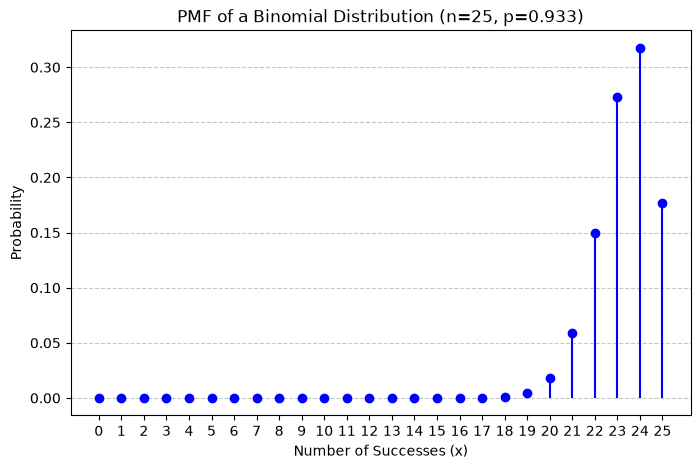

In [149]:
# for learning: check PMF distribution for event with higher occurance
ames["has_central_ac"] = ames["Central_Air"] == "Y"
ames["has_central_ac"] = ames["has_central_ac"].astype(int)

# success rate
ac_success_p = ames["has_central_ac"].mean()
print(f"True Central AC Probability: {ac_success_p * 100}%")

# k(expected value)
k = n * ac_success_p
print(f"Expected value: {k}")

# PMF
print(f"Probability of getting {round(k,0)} houses with central AC in your sample {round(scipy.stats.binom.pmf(round(k,0), n, ac_success_p) * 100,2)}%")

# plot
pmf_values = scipy.stats.binom.pmf(x,n,ac_success_p)

# Create the stem plot
plt.figure(figsize=(8, 5))
plt.stem(x, pmf_values, basefmt=" ", linefmt="b-", markerfmt="bo")

# Format the plot
plt.title(f"PMF of a Binomial Distribution (n=25, p={round(ac_success_p,3)})")
plt.xlabel("Number of Successes (x)")
plt.ylabel("Probability")
plt.xticks(x)  # Force integer ticks on x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [150]:
print(f"Probability of getting 21 houses or more with AC is {round(scipy.stats.binom.sf(20,n,ac_success_p) * 100,2)}%")

Probability of getting 21 houses or more with AC is 97.69%


* Between the PMF of fairly new house and central ac conditions, it seems like the fairly new house is more bell shaped/less skewed than the distribution of the central ac condition. I believe that its most likely due to the fact that central AC presence is much more common (almost 93%) so the probability of anything else occuring/house with no AC is much lower.

### Binomial — wrap-up

**What it models:** the number of "successes" in `n` independent trials, each with the same fixed probability `p` of success.

**Assumptions to check before reaching for it:**
- Exactly two outcomes per trial (success/failure).
- `p` is fixed and identical across all trials.
- Trials are independent. Sampling *without* replacement from a finite population technically breaks this (each draw changes the remaining pool), but the violation is negligible when the sample is small relative to the population — as it was here, 25 out of ~2,930 rows.
- `n` is fixed in advance, not decided based on results as you go.

**Key quantities:**
- PMF `P(X = k)`: probability of landing on exactly `k` successes.
- CDF `P(X ≤ k)`: cumulative probability up to and including `k`.
- SF `P(X > k)`: complement of the CDF. Note the off-by-one — `P(X ≥ k)` is `SF(k-1)`, not `SF(k)`.
- Mean = `n·p`, Variance = `n·p·(1-p)`.

**When the normal approximation holds:** both `n·p` and `n·(1-p)` need to be reasonably large (rule of thumb: ≥5). If either is small — which happens whenever `p` sits close to 0 or 1 — the distribution stays skewed no matter how large `n` is, as seen with `Central_Air` (`p≈0.93`, `n·(1-p)≈1.67`) versus `is_new` (`p≈0.27`, both terms comfortably ≥5).

**Applied here:** `is_new` (`Year_Built ≥ 2000`) and `has_central_ac` as two Ames conditions — built the full PMF, a tail probability, cross-checked against an actual random draw, then compared shapes to see the normal approximation hold for one and break down for the other.

## 2. Chi-Square Distribution

*Scaffolding — concrete version, no jargon up front:* a **standard normal value** is just a random draw from the normal curve centered at 0 with a spread of 1 (most draws land between about -3 and 3). Here's the whole recipe for building a chi-square distribution, using `df=3` as an example:

1. Draw `df` independent standard normal values — e.g. three draws: `0.8`, `-1.5`, `0.3`.
2. Square each one: `0.64`, `2.25`, `0.09`.
3. Add them up: `2.98`.

That single number, `2.98`, is *one draw* from a chi-square distribution with `df=3` degrees of freedom. "Degrees of freedom" is really just "how many standard normal values you summed the squares of." Repeat steps 1-3 thousands of times and histogram the results to see the actual distribution shape (not just one draw).

**Why it matters for stats:** sample variance is built from squared deviations from the mean (`Σ(xᵢ - x̄)²`). Under normality, those deviations behave like scaled standard-normal values, so their sum of squares behaves like a chi-square variable — that's why chi-square shows up whenever you're estimating variance, and it's also the basis of Ch 3's chi-square test (same idea, applied to counts instead of continuous deviations).

1. Simulate it: pick a `df` (try a couple, e.g. 2, 5, 15), repeat the 3-step recipe above many times, and compare your histogram of sums against `scipy.stats.chi2(df=df).pdf(...)`. Watch how the shape changes with `df` — where does the skew go, and where does the mode sit relative to `df`?
2. Connect it to Ames: take a numeric column (e.g. `Gr_Liv_Area` for a single `Neighborhood`, to keep the sample small) and use the fact that `(n-1) * sample_variance / population_variance` follows a chi-square distribution with `n-1` degrees of freedom to build a confidence interval for the *population variance* of that column. Sanity check the interval against the variance of the full-dataset column for that same feature.

In [151]:
# establish df
df = [2,5,15]

# build chi square distribution and chi2 pdf comparison
def build_chi_square_dist(df, iterations):
    main_list = {"Df Tested" : df, "Sum of Squares" : []}
    print(f"Chi Square Distribution For df: {df}")

    for i in range(0,iterations):
        draws = np.random.standard_normal(size = df)
        draws_sq = draws**2
        main_list["Sum of Squares"].append(draws_sq.sum())

    # pdf results
    sorted_sums = sorted(main_list["Sum of Squares"])
    chi2_pdf = scipy.stats.chi2(df=df).pdf(sorted_sums)

    # plot the historgram using subplots
    plt.hist(main_list["Sum of Squares"], density=True, color = "skyblue", bins = 30)
    plt.title(f"Chi Distribution With DF: {df}")
    plt.xlabel("Sum of Squares (Bin = 30)")
    plt.plot(sorted_sums, chi2_pdf, label = "scipy density value")
    plt.show()
    



Chi Square Distribution For df: 2


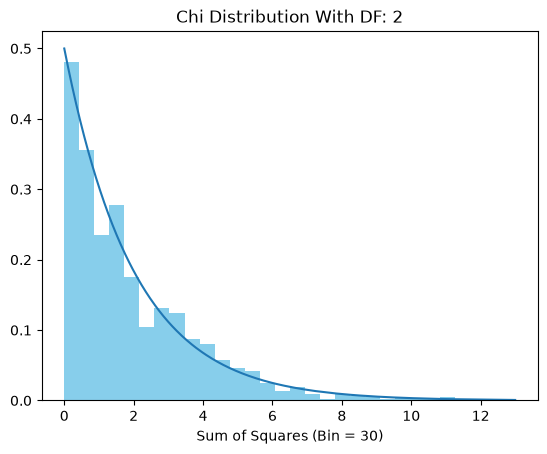

Chi Square Distribution For df: 5


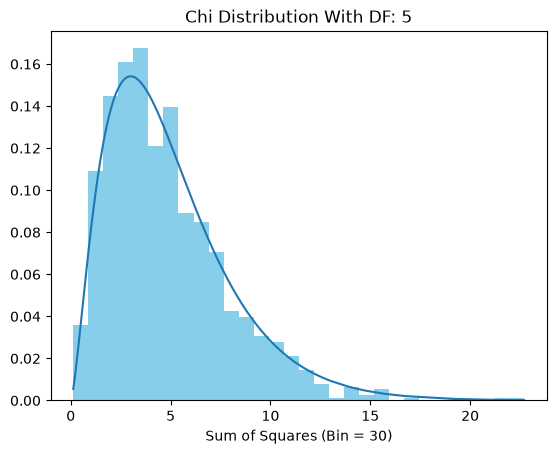

Chi Square Distribution For df: 15


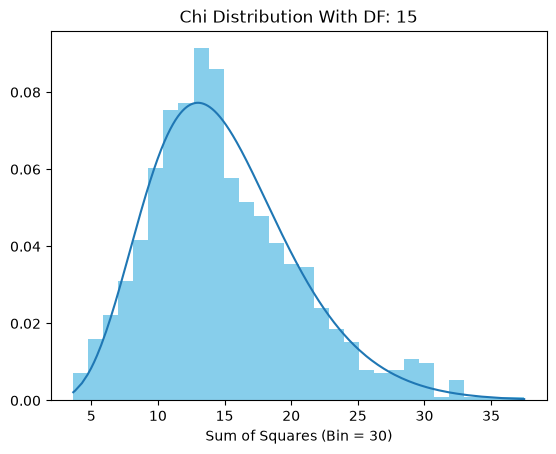

In [152]:
# loop through the dfs
for i in df:
    build_chi_square_dist(i, 1000)

**What the chi-square distribution represents, in plain terms:** it's the answer to "if I keep repeating 'draw `df` standard normal values, square them, add them up,' what does the spread of results look like?" It's not a distribution you'd normally observe directly in the world (like house prices) — it's the distribution of a specific arithmetic outcome (that sum) produced by a specific repeated random process. Because it's a sum of squares, it can never go negative, and larger `df` means more terms get added up, so both the typical size and the spread of the sums grow with `df` (that's why the curves shifted right and got wider as `df` went from 2 to 15 in your plots).

**What `.pdf()` converts a sum-of-squares value into:** given one specific value (e.g. `7.2`), it returns a *relative density*, not a probability — a number saying how "crowded" that value is compared to its neighbors, given `df`. A taller pdf value means values in that neighborhood turn up more often across repeated draws; a shorter one means that neighborhood is rare. It's not a probability on its own (it can exceed 1, and doesn't sum to 1 the way a PMF does) — to get an actual probability you'd integrate the pdf over a range, which is what `.cdf()`/`.sf()` do under the hood. The main use here is exactly what you did with it: compare its shape against the histogram of your simulated sums.

In [155]:
# ames practice
# select one column and set sample to one neighborhood
col = "Gr_Liv_Area"
neighborhood_sample = ames[ames["Neighborhood"] == "North_Ames"][col]

n = len(neighborhood_sample)               # scalar count, not a per-column Series
sample_var = neighborhood_sample.var(ddof=1)  # ddof=1 -> divide by (n-1), the *sample* variance
print(f"Sample size (n): {n}")
print(f"Sample variance (s^2): {sample_var:.1f}")

Sample size (n): 443
Sample variance (s^2): 147903.5


**Step 1 — what just happened:** `neighborhood_sample` is your "sample" (443 North_Ames houses' `Gr_Liv_Area` values). `n` is how many observations you have; `sample_var` (`s²`) is your best single-number guess at the *true* variance of house size across all possible North_Ames houses. The whole point of this section is that `s²` alone is just a point estimate — it doesn't tell you how much to trust it. The chi-square relationship is what turns it into a range.

In [156]:
# build confidence interval
confidence = 0.95
alpha = 1 - confidence
df = n - 1

# the two chi-square cutoff values that trap the middle 95% of chi2(df)
chi2_lower_crit = scipy.stats.chi2.ppf(alpha / 2, df)        # 2.5th percentile
chi2_upper_crit = scipy.stats.chi2.ppf(1 - alpha / 2, df)    # 97.5th percentile
print(f"df: {df}")
print(f"chi2 cutoffs: ({chi2_lower_crit:.2f}, {chi2_upper_crit:.2f})")

df: 442
chi2 cutoffs: (385.64, 502.14)


**Step 2 — what just happened:** `.ppf()` (percent-point function) is the *reverse* of `.pdf()`/`.cdf()` — you give it a probability, it gives you back the value. `chi2.ppf(0.025, df)` asks "what value has only 2.5% of the chi2(df) distribution below it?" and `chi2.ppf(0.975, df)` asks the mirror question for the top 2.5%. Together they bracket the middle 95% of the distribution — the same chi2(df) curve shape you plotted earlier, just read off its x-axis at two specific probabilities instead of reading its height at a given x.

In [157]:
# the pivotal fact: (n-1)*sample_var / population_var ~ chi2(df)
# P(chi2_lower_crit <= (n-1)*sample_var/population_var <= chi2_upper_crit) = 0.95
# rearranged to isolate population_var in the middle:
ci_lower = (n - 1) * sample_var / chi2_upper_crit   # note: divide by the UPPER cutoff for the LOWER bound
ci_upper = (n - 1) * sample_var / chi2_lower_crit   # and by the LOWER cutoff for the UPPER bound
print(f"{confidence*100:.0f}% CI for population variance: ({ci_lower:.1f}, {ci_upper:.1f})")

95% CI for population variance: (130188.3, 169517.9)


**Step 3 — what just happened, especially the swapped division:** starting from `chi2_lower_crit ≤ (n-1)·s²/σ² ≤ chi2_upper_crit` and solving for `σ²` in the middle flips the direction of each inequality, because dividing flips inequalities the same way multiplying by a negative does. That's *why* the lower bound uses the upper cutoff, and the upper bound uses the lower cutoff — it looks backwards until you walk through the algebra, but it's not a typo.

In [158]:
# sanity check: does the full-dataset variance for this column fall inside the interval?
full_dataset_var = ames[col].var(ddof=1)
print(f"Full-dataset variance (all neighborhoods): {full_dataset_var:.1f}")
print(f"North_Ames-only 95% CI: ({ci_lower:.1f}, {ci_upper:.1f})")
print(f"Falls inside the interval? {ci_lower <= full_dataset_var <= ci_upper}")

Full-dataset variance (all neighborhoods): 255539.2
North_Ames-only 95% CI: (130188.3, 169517.9)
Falls inside the interval? False


**Step 4 — interpreting the sanity check:** running this, the full-dataset variance lands *outside* the North_Ames-only interval (the interval is narrower and shifted lower). That's not a bug in the math — it's a real, meaningful result: `Gr_Liv_Area` varies less *within* one neighborhood than it does *across* all of Ames, because neighborhoods aren't random subsets of the housing stock — they cluster by house size/era/price tier. Your CI correctly describes "how spread out house sizes are within North_Ames," and that's genuinely a different (smaller) quantity than "how spread out house sizes are across the entire city." This is the same idea Ch 3's ANOVA will formalize later: group membership (here, neighborhood) can explain a real chunk of variance, so pooling all groups together inflates it.

**Your notes (bullet points):**

- 

## 3. Poisson Distribution

`Fireplaces` is a count per house — a natural candidate for "number of times a somewhat-rare thing happens."

1. Compute the empirical distribution of `Fireplaces` values across all of Ames. Fit a Poisson distribution using the sample mean as `lambda`, and overlay the fitted Poisson PMF against the empirical bar chart.
2. Does it fit well? If not, where does it break down — and does that suggest `Fireplaces` isn't well modeled as independent rare events (think about what determines whether a house has a fireplace)?
3. Optional callback to section 2: use a chi-square goodness-of-fit test (`scipy.stats.chisquare`) to put a number on how well the Poisson model fits the observed counts.

In [184]:
# empirical counts + Poisson expected counts, using the full dataset
fire_counts = ames["Fireplaces"].value_counts().sort_index()
sample_mean = ames["Fireplaces"].mean()

n = len(ames)
k = fire_counts.index

poisson_results = stats.poisson.pmf(k, mu=sample_mean) * n
# fold the tail beyond the largest observed count (P(X >= max) instead of P(X = max))
# into the last bin, so the expected counts sum to n just like the observed counts do
poisson_results[-1] = stats.poisson.sf(k[-1] - 1, mu=sample_mean) * n

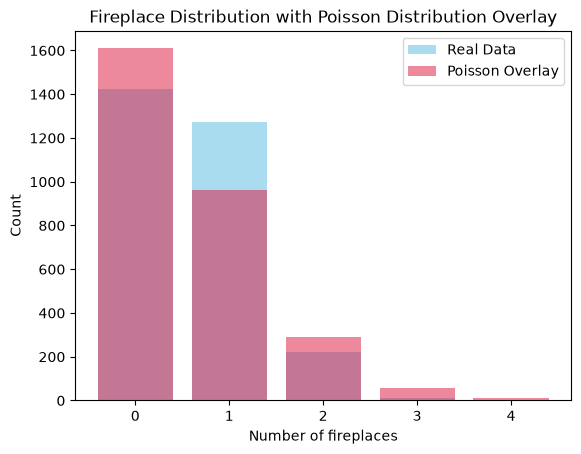

In [185]:
plt.bar(fire_counts.index, fire_counts.values, color="skyblue", alpha=0.7, label="Real Data")
plt.bar(k, poisson_results, color="crimson", alpha=0.5, label="Poisson Overlay")

plt.xlabel("Number of fireplaces")
plt.ylabel("Count")
plt.title("Fireplace Distribution with Poisson Distribution Overlay")
plt.legend()

plt.show()

In [186]:
result = stats.chisquare(f_obs=fire_counts.values, f_exp=poisson_results)
print(result)

Power_divergenceResult(statistic=np.float64(181.29004988169564), pvalue=np.float64(3.939805208008797e-38))


**What Poisson represents, in plain terms:** it's a model for "how many times does a somewhat-rare thing happen in a fixed window," assuming two things: each occurrence is independent of the others, and the average rate (`lambda`) stays constant across every house. Think of it like this: if fireplaces were handed out completely at random — same odds for every house, regardless of size or price — the counts you'd see across thousands of houses would settle into a Poisson shape. One number, `lambda` (here, the dataset's average number of fireplaces per house, ≈0.6), fully determines the whole distribution: how many houses get 0, how many get 1, how many get 2, and so on.

**What `pmf(k) * n` gives you:** "if the Poisson story above were true, how many of our `n` houses would we *expect* to land on exactly `k` fireplaces?" That turns a probability into a head count you can directly compare against what you actually observed — which is exactly the red-vs-blue comparison in your plot.

**What the result actually says:** the chi-square test came back with an astronomically small p-value (≈4×10⁻³⁸), meaning the observed counts are essentially incompatible with the Poisson story — this isn't a borderline call. Visually, this shows up as real houses having noticeably *more* 0-fireplace and 1-fireplace houses than Poisson predicts, and the gap widens further out. The likely reason: whether a house has a fireplace isn't decided independently at some fixed rate — it tracks house size, quality, and price. A tiny starter home and a large luxury home don't have the same "odds" of getting a fireplace, which is exactly the assumption Poisson needs and this data breaks.

**Your notes (bullet points):**

- 